# Import Liberies and the datasheet

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\Shiva\OneDrive\Desktop\Python Lib\Practice\EDA\Titanic\Titanic-Dataset.csv" , low_memory= False)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [2]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# BASIC INFORMATION

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Basic Data Cleaning

#Check if and Column has null object

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Fix few common issues 

In [6]:
# Convert object to category (for categorical variables)
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

So we have 24.78 percent of missing rows in Age so we will fill it

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())      # Fill missing values
df['Age']

0      22.00
1      38.00
2      26.00
3      35.00
4      35.00
5      28.00
6      54.00
7       2.00
8      27.00
9      14.00
10      4.00
11     58.00
12     20.00
13     39.00
14     14.00
15     55.00
16      2.00
17     28.00
18     31.00
19     28.00
20     35.00
21     34.00
22     15.00
23     28.00
24      8.00
25     38.00
26     28.00
27     19.00
28     28.00
29     28.00
30     40.00
31     28.00
32     28.00
33     66.00
34     28.00
35     42.00
36     28.00
37     21.00
38     18.00
39     14.00
40     40.00
41     27.00
42     28.00
43      3.00
44     19.00
45     28.00
46     28.00
47     28.00
48     28.00
49     18.00
50      7.00
51     21.00
52     49.00
53     29.00
54     65.00
55     28.00
56     21.00
57     28.50
58      5.00
59     11.00
60     22.00
61     38.00
62     45.00
63      4.00
64     28.00
65     28.00
66     29.00
67     19.00
68     17.00
69     26.00
70     32.00
71     16.00
72     21.00
73     26.00
74     32.00
75     25.00
76     28.00

About Missing Cabins 

In [8]:
df = df.drop(columns=['Cabin'])

In [9]:
print(df.dtypes)  # Check the data types 

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
dtype: object


Check for Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

# ***Titanic Survival Analysis:***

****Data Overview & Quality Assessment****

What is the size of the dataset (rows × columns)?

In [11]:
print('There are ',df.shape[0],' rows and ',df.shape[1],' columns')

There are  891  rows and  11  columns


How many variables are in the dataset? What are their types?

In [12]:
df.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
dtype: object

<Axes: xlabel='Is_Alone', ylabel='count'>

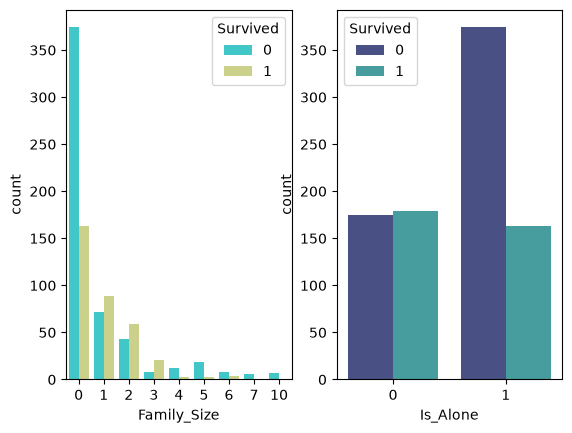

In [13]:
df['Family_Size'] = df['SibSp'] + df['Parch']
df['Is_Alone'] = (df['Family_Size'] == 0).astype(int)
df[['Family_Size','Is_Alone']]
plt.subplot(1,2,1)
sns.countplot(x= df['Family_Size'],palette='rainbow',hue='Survived',data=df)
plt.subplot(1,2,2)
sns.countplot(x= df['Is_Alone'],palette='mako',hue='Survived',data=df)


Which family size had the highest and lowest survival rate?

In [14]:
df.groupby('Family_Size')['Survived'].mean().nlargest(2)

Family_Size
3    0.724138
2    0.578431
Name: Survived, dtype: float64

In [15]:
df.groupby('Family_Size')['Survived'].mean().nsmallest(2)

Family_Size
7     0.0
10    0.0
Name: Survived, dtype: float64

In [16]:
Family_rate = df.groupby('Family_Size')['Survived'].mean()
Family_df = pd.DataFrame({
    'Family_Size': Family_rate.index,
    'Survival_rate': Family_rate.values
})
Family_df.head(50)

,Family_Size,Survival_rate
0,0,0.303538
1,1,0.552795
2,2,0.578431
3,3,0.724138
4,4,0.200000
5,5,0.136364
6,6,0.333333
7,7,0.000000
8,10,0.000000


<Axes: xlabel='Family_Size', ylabel='Survival_rate'>

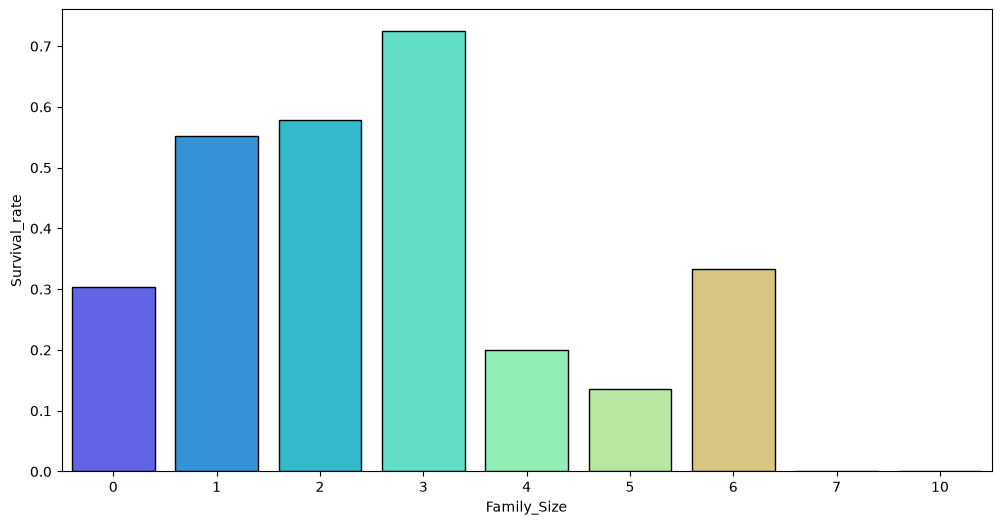

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(x= Family_df['Family_Size'],y= Family_df['Survival_rate'], edgecolor='black',palette='rainbow')

no. of females and male that survived

In [18]:
Number_of_male_and_female_passengers = df['Sex'].value_counts()
Number_of_male_and_female_passengers

Sex
male      577
female    314
Name: count, dtype: int64

In [19]:
Count_ = df.groupby('Sex')['Survived'].value_counts()
Count_

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

Rate of survival according to gender

In [20]:
Rate = df.groupby('Sex')['Survived'].mean()
Rate

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

<Axes: xlabel='Sex'>

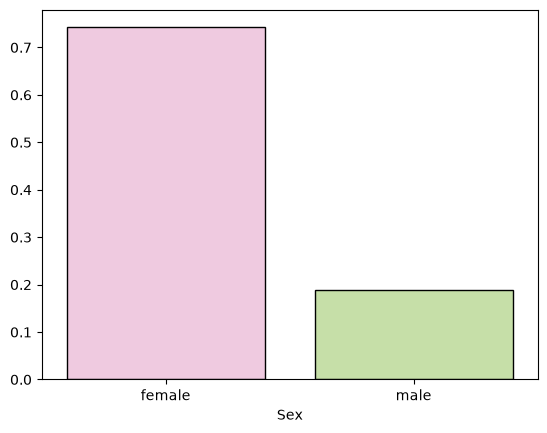

In [21]:
sns.barplot(x= Rate.index, y= Rate.values,palette='PiYG',edgecolor='black')

Count of male and female died and survived

<Axes: xlabel='Sex', ylabel='count'>

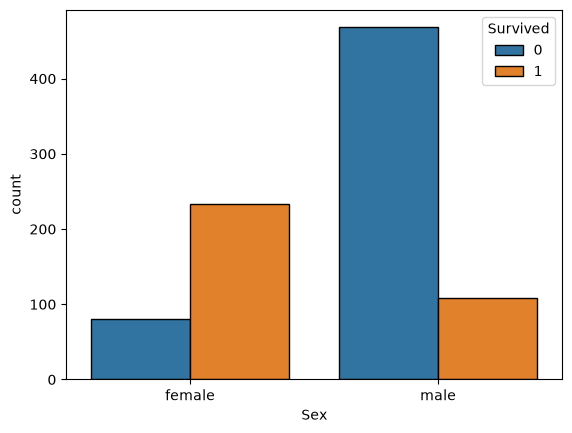

In [22]:
sns.countplot(x= df['Sex'],hue= 'Survived',data= df,edgecolor='black')

Survival Rate according to class

In [23]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Text(42.722222222222214, 0.5, 'Rate of survival')

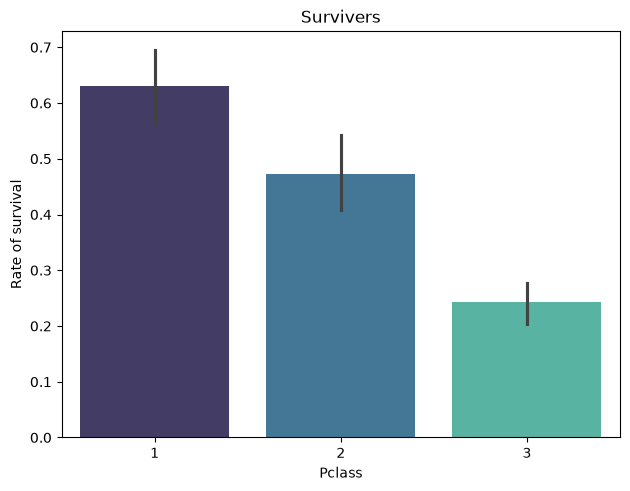

In [24]:
sns.barplot(x= 'Pclass',y= 'Survived',data= df,palette= 'mako')
plt.tight_layout()
plt.title('Survivers')
plt.ylabel('Rate of survival')

Avg age of survivor vs non servivor

In [25]:
df.groupby('Survived')['Age'].mean()

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

<Axes: xlabel='Survived', ylabel='Age'>

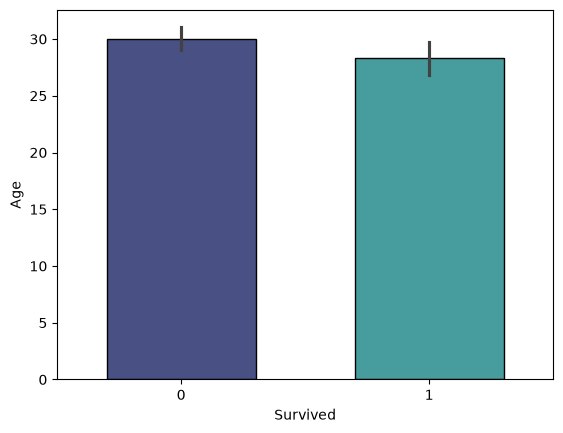

In [26]:
sns.barplot(x= 'Survived',y= 'Age',data= df,edgecolor='black',width= 0.6,palette='mako')

In [27]:
df.groupby('Survived')['Fare'].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

In [28]:
#best combo for survival
df.groupby(['Sex', 'Pclass'])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

Age vs survival

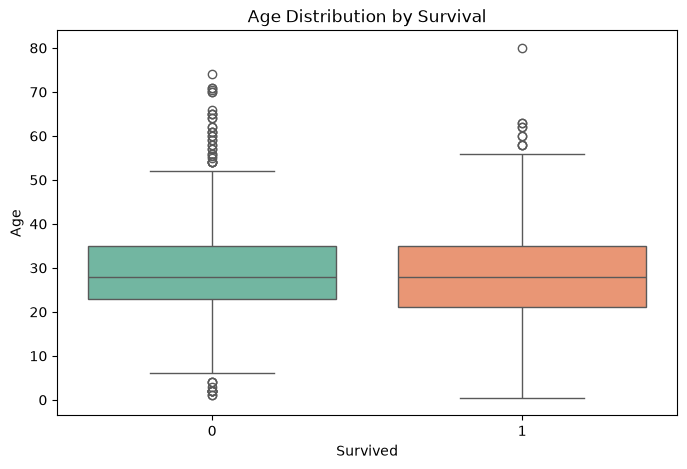

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Survived'], y=df['Age'], palette='Set2')
plt.title('Age Distribution by Survival')
plt.show()

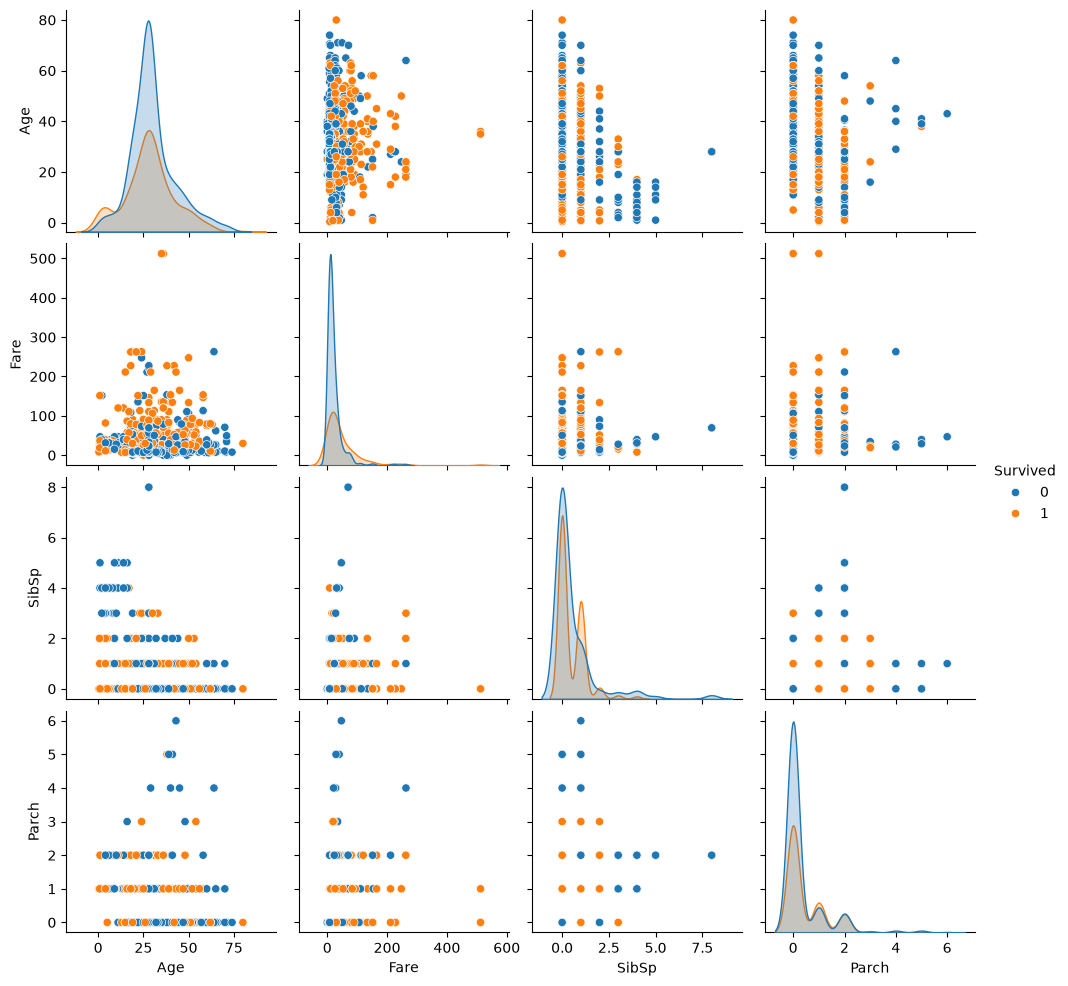

In [30]:
sns.pairplot(df[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']], hue='Survived')
plt.show()